# Tiled Scoring Workflow Demo


## About the demo data

This notebook runs a multitile scoring workflow using the combined setup CSV and `batch_config.json`, then inspects tile-specific outputs.


## Prerequisites

This notebook assumes `sortscore` is installed and available in the same Python environment as the Jupyter kernel.

Recommended setup (outside this notebook, in terminal from repository root):
```bash
python -m venv .venv
source .venv/bin/activate
pip install -e .
pip install ipykernel
python -m ipykernel install --user --name=sortscore-venv --display-name="Python (sortscore venv)"
```

After setup, select that kernel for this notebook.

In [19]:
import importlib.util
import shutil

cli_path = shutil.which("sortscore")
pkg_ok = importlib.util.find_spec("sortscore") is not None

if cli_path or pkg_ok:
    print("sortscore is installed in this environment.")
    if cli_path:
        print(f"CLI path: {cli_path}")
else:
    print("sortscore is not installed in this environment.")
    print("See installation guide: docs/installation.md")

sortscore is installed in this environment.
CLI path: /Users/c.chitwood/code/sortscore/venv/bin/sortscore


## 1) Set run inputs


In [20]:
from pathlib import Path
import sys

EXPERIMENT_NAME = "test_multitile_regression"
TARGET_TILE = 2
EXPERIMENT_SETUP_PATH = "demo_data/combined_experiment_setup.csv"
CONFIG_PATH = "demo_data/batch_config.json"

def resolve_path(path_str):
    path = Path(path_str)
    candidates = [path, Path("..") / path]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    return path

EXPERIMENT_SETUP_FILE = resolve_path(EXPERIMENT_SETUP_PATH)
CONFIG_FILE = resolve_path(CONFIG_PATH)

print(f"experiment_setup: {EXPERIMENT_SETUP_FILE}")
print(f"config: {CONFIG_FILE}")
print(f"target_tile: {TARGET_TILE}")


experiment_setup: /Users/c.chitwood/code/sortscore/demo_data/combined_experiment_setup.csv
config: /Users/c.chitwood/code/sortscore/demo_data/batch_config.json
target_tile: 2


## 2) Run tile scoring workflow
If sortscore has been pip installed in the environment, this snippet will use the `sortscore score` subcommand directly in the CLI. If not, it will run as a module. Behavior and outputs are the same in either case.

In [21]:
import shutil
import subprocess
def supports_subcommands() -> bool:
    if not shutil.which("sortscore"):
        return False
    proc = subprocess.run(["sortscore", "--help"], capture_output=True, text=True)
    help_text = (proc.stdout or "") + "\n" + (proc.stderr or "")
    return "<score|norm>" in help_text or "sortscore <score|norm>" in help_text

In [22]:
import sys

if supports_subcommands():
    score_cmd = f"sortscore score -n {EXPERIMENT_NAME} -e {EXPERIMENT_SETUP_FILE} -c {CONFIG_FILE}"
else:
    score_cmd = f"{sys.executable} -m sortscore score -n {EXPERIMENT_NAME} -e {EXPERIMENT_SETUP_FILE} -c {CONFIG_FILE}"

print(score_cmd)
!{score_cmd}


/Users/c.chitwood/code/sortscore/venv/bin/python -m sortscore score -n test_multitile_regression -e /Users/c.chitwood/code/sortscore/demo_data/combined_experiment_setup.csv -c /Users/c.chitwood/code/sortscore/demo_data/batch_config.json
INFO:root:Detected 2 tiles. Running scoring independently per tile using one shared setup file.
INFO:root:Running tile 1: output_dir=_test_outputs/multitile_output/tile1
INFO:root:Using mutagenesis_type: 'codon'
INFO:root:Loaded counts for 3 replicates.
Counts loaded.
INFO:sortscore.utils.analysis_logger:Analysis logger initialized: test_multitile_regression_tile1_20260724_121801
INFO:root:Using mutagenesis_type: 'codon'
INFO:root:Processing DNA workflow
INFO:root:Calculated DNA scores for 2081 variants.
INFO:root:Saved DNA scores to /Users/c.chitwood/code/sortscore/demo_data/_test_outputs/multitile_output/tile1/scores/test_multitile_regression_tile1_dna_scores.csv
INFO:sortscore.utils.analysis_logger:Logged output file: dna_scores -> test_multitile_reg

## 3) Run across-tile normalization workflow


In [23]:
if supports_subcommands():
    norm_cmd = f"sortscore norm -c {CONFIG_FILE}"
else:
    norm_cmd = f"{sys.executable} -m sortscore norm -c {CONFIG_FILE}"

print(norm_cmd)
!{norm_cmd}


/Users/c.chitwood/code/sortscore/venv/bin/python -m sortscore norm -c /Users/c.chitwood/code/sortscore/demo_data/batch_config.json
INFO:root:Loaded batch config with 2 tiles
INFO:sortscore.analysis.batch_normalization:Starting batch normalization workflow
INFO:sortscore.analysis.batch_normalization:Loaded batch config entry 1: tile=1, output_dir=/Users/c.chitwood/code/sortscore/demo_data/_test_outputs/multitile_output/tile1
INFO:sortscore.analysis.batch_normalization:Loaded batch config entry 2: tile=2, output_dir=/Users/c.chitwood/code/sortscore/demo_data/_test_outputs/multitile_output/tile2
INFO:sortscore.analysis.batch_normalization:Combined 4162 variants from 2 experiments
INFO:sortscore.analysis.batch_normalization:Applying z-score scaled 2-pole normalization
INFO:sortscore.analysis.batch_normalization:Z-score 2-pole normalization complete
INFO:sortscore.analysis.batch_normalization:Normalized 4162 DNA rows with zscore_2pole
INFO:sortscore.analysis.batch_normalization:Combined 139

## 4) Resolve tile and batch output files


In [24]:
import json
import pandas as pd
from IPython.display import Image, Markdown, display

with open(CONFIG_FILE, "r", encoding="utf-8") as f:
    config = json.load(f)

tile_entry = next((e for e in config.get("experiments", []) if int(e.get("tile", -1)) == int(TARGET_TILE)), None)
tile_experiment_name = f"{EXPERIMENT_NAME}_tile{TARGET_TILE}"

if tile_entry is None:
    print(f"No tile entry found for tile={TARGET_TILE} in batch config.")
    scores_dir = None
    figures_dir = None
    aa_stats_file = None
    dna_stats_file = None
    aa_scores_file = None
    dna_scores_file = None
    aa_heatmap_file = None
    codon_heatmap_file = None
else:
    output_dir_cfg = Path(tile_entry.get("output_dir", "output"))
    if output_dir_cfg.is_absolute():
        output_dir = output_dir_cfg
    else:
        output_dir = (CONFIG_FILE.parent / output_dir_cfg).resolve()

    scores_dir = output_dir / "scores"
    figures_dir = output_dir / "figures"

    aa_stats_file = scores_dir / f"{tile_experiment_name}_aa_stats.json"
    dna_stats_file = scores_dir / f"{tile_experiment_name}_dna_stats.json"
    aa_scores_file = scores_dir / f"{tile_experiment_name}_aa_scores.csv"
    dna_scores_file = scores_dir / f"{tile_experiment_name}_dna_scores.csv"
    aa_heatmap_file = figures_dir / f"{tile_experiment_name}_aa_heatmap.png"
    codon_heatmap_file = figures_dir / f"{tile_experiment_name}_codon_heatmap.png"

combined_output_cfg = Path(config.get("combined_output_dir", "normalized"))
if combined_output_cfg.is_absolute():
    combined_output_root = combined_output_cfg
else:
    combined_output_root = (CONFIG_FILE.parent / combined_output_cfg).resolve()

norm_method = config.get("batch_normalization_method", "zscore_2pole")
combined_output_dir = combined_output_root / "normalized" / norm_method

batch_scores_dir = combined_output_dir / "scores"
batch_figures_dir = combined_output_dir / "figures"

batch_stats_file = batch_scores_dir / "batch_stats.json"
batch_dna_scores_file = batch_scores_dir / "batch_dna_scores.csv"
batch_aa_scores_file = batch_scores_dir / "batch_aa_scores.csv"
tiled_heatmap_file = batch_figures_dir / "tiled_heatmap.png"
combined_aa_heatmap_file = batch_figures_dir / "combined_aa_heatmap.png"


## 5) Print tile and batch stats JSON


In [25]:
for label, stats_file in [("Tile AA", aa_stats_file), ("Tile DNA", dna_stats_file)]:
    if stats_file is None or not stats_file.exists():
        location = stats_file if stats_file is not None else "<unresolved>"
        print(f"No {label} stats JSON found at {location}.")
        continue

    display(Markdown(f"### {label} stats (`{stats_file.name}`)"))
    with open(stats_file, "r", encoding="utf-8") as f:
        stats = json.load(f)
    print(json.dumps(stats, indent=2))

if not batch_stats_file.exists():
    print(f"No batch stats JSON found at {batch_stats_file}.")
else:
    display(Markdown(f"### Batch stats (`{batch_stats_file.name}`)"))
    with open(batch_stats_file, "r", encoding="utf-8") as f:
        batch_stats = json.load(f)
    print(json.dumps(batch_stats, indent=2))


### Tile AA stats (`test_multitile_regression_tile2_aa_stats.json`)

{
  "overall": {
    "avg": 1246.981,
    "median": 1372.133,
    "min": 218.835,
    "max": 2344.047,
    "std": 497.97
  },
  "synonymous_wt": {
    "avg": 1498.526,
    "median": 1541.659,
    "min": 905.816,
    "max": 2052.102,
    "std": 269.84
  },
  "nonsense": {
    "avg": 292.932,
    "median": 284.183,
    "min": 218.835,
    "max": 426.509,
    "std": 48.83
  },
  "missense": {
    "avg": 1284.709,
    "median": 1387.223,
    "min": 302.06,
    "max": 2344.047,
    "std": 466.29
  }
}


### Tile DNA stats (`test_multitile_regression_tile2_dna_stats.json`)

{
  "overall": {
    "avg": 1243.238,
    "median": 1323.46,
    "min": 111.172,
    "max": 2691.641,
    "std": 583.36
  },
  "wt": {
    "avg": 1485.246,
    "median": 1485.246,
    "min": 1485.246,
    "max": 1485.246,
    "std": 0
  },
  "synonymous_wt": {
    "avg": 1510.345,
    "median": 1558.643,
    "min": 635.023,
    "max": 2264.395,
    "std": 400.2
  },
  "nonsense": {
    "avg": 292.932,
    "median": 284.183,
    "min": 218.835,
    "max": 426.509,
    "std": 48.83
  },
  "missense": {
    "avg": 1284.709,
    "median": 1387.223,
    "min": 302.06,
    "max": 2344.047,
    "std": 466.29
  }
}


### Batch stats (`batch_stats.json`)

{
  "dna": {
    "raw": {
      "global": {
        "reference_type": "synonymous",
        "reference_median": 1762.3390772126713
      },
      "tile1": {
        "syn_median": 2174.079692819394
      },
      "tile2": {
        "syn_median": 1558.643312516222
      }
    },
    "wt_alignment": {
      "global": {
        "syn_avg": 1695.34366038889,
        "syn_median": 1762.3390772126713,
        "syn_std": 427.1069311983365
      },
      "tile1": {
        "normalization_factor": 0.8106138349175377
      },
      "tile2": {
        "normalization_factor": 1.130687863644447
      }
    },
    "zscore": {
      "global": {
        "non_avg_zscore": -3.060075020295365
      },
      "tile1": {
        "non_avg_zscore": -2.9262675450557674,
        "pathogenic_normalization_factor": 1.0457263299337338
      },
      "tile2": {
        "non_avg_zscore": -3.1938824955349623,
        "pathogenic_normalization_factor": 0.9581050726109492
      }
    },
    "final": {
      "global": {
 

## 6) Show tile and batch score table heads


In [26]:
if aa_scores_file is None or not aa_scores_file.exists():
    location = aa_scores_file if aa_scores_file is not None else "<unresolved>"
    print(f"No amino-acid scores CSV found for this tile at {location}.")
else:
    display(Markdown(f"### Tile amino-acid scores (`{aa_scores_file.name}`)"))
    display(pd.read_csv(aa_scores_file).head())

if dna_scores_file is None or not dna_scores_file.exists():
    location = dna_scores_file if dna_scores_file is not None else "<unresolved>"
    print(f"No DNA/codon scores CSV found for this tile at {location}.")
else:
    display(Markdown(f"### Tile DNA/codon scores (`{dna_scores_file.name}`)"))
    display(pd.read_csv(dna_scores_file).head())

if not batch_aa_scores_file.exists():
    print(f"No batch-normalized AA scores CSV found at {batch_aa_scores_file}.")
else:
    display(Markdown(f"### Batch-normalized AA scores (`{batch_aa_scores_file.name}`)"))
    display(pd.read_csv(batch_aa_scores_file).head())

if not batch_dna_scores_file.exists():
    print(f"No batch-normalized DNA scores CSV found at {batch_dna_scores_file}.")
else:
    display(Markdown(f"### Batch-normalized DNA scores (`{batch_dna_scores_file.name}`)"))
    display(pd.read_csv(batch_dna_scores_file).head())


### Tile amino-acid scores (`test_multitile_regression_tile2_aa_scores.csv`)

,aa_seq_diff,annotate_aa,score,Rep1.score,Rep2.score,Rep3.score,count.r1b1,count.r1b2,count.r1b3,count.r1b4,...,count.r3b1,count.r3b2,count.r3b3,count.r3b4,SD_rep,CV_rep,n_measurements,SEM,CI_lower,CI_upper
0,=,wt_dna,1485.246488,1525.472277,1572.560273,1351.505316,6552766.0,8316666.0,21253668,16887852.0,...,6358087.0,10043846.0,17639856.0,17566153.0,116.438165,0.079,3,67.225606,1193.930853,1772.427724
1,A.26.*,nonsense,287.597150,290.787376,304.039270,267.207683,119855.0,39449.0,8735,3480.0,...,94310.0,65022.0,21321.0,4718.0,18.655564,0.065,3,10.770795,241.001786,333.687767
2,A.26.=,synonymous,1728.596331,1756.198955,1937.148452,1497.793512,14954.0,32285.0,93110,102610.0,...,22028.0,59166.0,89386.0,111542.0,220.812460,0.128,3,127.486133,1181.851746,2278.908866
3,A.26.C,missense_aa,939.906784,964.817510,1055.965526,775.895896,74856.0,67407.0,29694,23645.0,...,76453.0,86697.0,46664.0,27382.0,142.850933,0.153,3,82.475024,577.364921,1287.087700
4,A.26.D,missense_aa,1817.488166,1932.894745,1642.424184,1981.061822,4976.0,17499.0,35349,48962.0,...,7815.0,27755.0,38803.0,56721.0,183.197827,0.099,3,105.769315,1397.038285,2307.215549


### Tile DNA/codon scores (`test_multitile_regression_tile2_dna_scores.csv`)

,variant_seq,count.r1b1,count.r1b2,count.r1b3,count.r1b4,count.r2b1,count.r2b2,count.r2b3,count.r2b4,count.r3b1,...,dna_seq_diff,aa_seq,aa_seq_diff,annotate_dna,annotate_aa,SD_rep,CV_rep,n_measurements,CI_lower,CI_upper
0,AAACCTGGCTGCACCAAGAGATACACCGACCCTAGCAGCCTGAGGA...,8195.0,24167.0,53644,103224.0,14899.0,30223.0,54252,102591.0,12987.0,...,"T.2.A, C.3.A",KPGCTKRYTDPSSLRKHVKTVHGPDAHVTKKQR,I.1.K,dinucleotide,missense_aa,117.729913,0.059,3,1690.387029,2275.301663
1,AACCCTGGCTGCACCAAGAGATACACCGACCCTAGCAGCCTGAGGA...,4441.0,8140.0,22312,50827.0,4012.0,12954.0,15015,71474.0,1744.0,...,T.2.A,NPGCTKRYTDPSSLRKHVKTVHGPDAHVTKKQR,I.1.N,snv,missense_aa,223.892079,0.102,3,1643.671399,2756.028913
2,AAGCCTGGCTGCACCAAGAGATACACCGACCCTAGCAGCCTGAGGA...,8438.0,6493.0,16931,26424.0,5834.0,13288.0,18054,36365.0,4440.0,...,"T.2.A, C.3.G",KPGCTKRYTDPSSLRKHVKTVHGPDAHVTKKQR,I.1.K,dinucleotide,missense_aa,19.683571,0.011,3,1809.947722,1907.741123
3,AATCCTGGCTGCACCAAGAGATACACCGACCCTAGCAGCCTGAGGA...,50567.0,83151.0,98158,98984.0,69898.0,104548.0,81567,127937.0,53167.0,...,"T.2.A, C.3.T",NPGCTKRYTDPSSLRKHVKTVHGPDAHVTKKQR,I.1.N,dinucleotide,missense_aa,81.816330,0.062,3,1113.193836,1519.679898
4,ACACCTGGCTGCACCAAGAGATACACCGACCCTAGCAGCCTGAGGA...,98.0,145.0,40,213.0,113.0,272.0,129,92.0,3.0,...,"T.2.C, C.3.A",TPGCTKRYTDPSSLRKHVKTVHGPDAHVTKKQR,I.1.T,dinucleotide,missense_aa,656.658000,0.435,3,-123.176003,3139.281802


### Batch-normalized AA scores (`batch_aa_scores.csv`)

,aa_seq_diff,annotate_aa,score,Rep1.score,Rep2.score,Rep3.score,count.r1b1,count.r1b2,count.r1b3,count.r1b4,...,count.r3b2,count.r3b3,count.r3b4,SD_rep,CV_rep,n_measurements,SEM,CI_lower,CI_upper,batch
0,=,wt_dna,0.040569,-1.198335,-0.104049,1.476532,3099944.0,2590471.0,6373923.0,9083203.0,...,2964639.0,6493695.0,9910647.0,537.128050,0.259,3,310.111024,742.297539,3410.897628,tile1
1,A.13.*,nonsense,-3.870118,-4.165494,-3.763960,-3.800611,47161.0,36737.0,16111.0,2979.0,...,38992.0,25885.0,2625.0,88.671879,0.180,3,51.194733,271.409822,711.956137,tile1
2,A.13.=,synonymous,-0.544519,-1.733986,-0.503012,0.638460,99927.0,45673.0,123360.0,173779.0,...,67338.0,127665.0,205987.0,473.909906,0.257,3,273.612012,663.326427,3017.841364,tile1
3,A.13.C,missense_aa,0.763198,-0.686441,0.580674,2.369422,23329.0,23001.0,63982.0,118553.0,...,26419.0,68696.0,133701.0,613.238288,0.260,3,354.053291,831.423909,3878.160623,tile1
4,A.13.D,missense_aa,-0.580489,-1.154018,-0.902747,0.378217,33469.0,40561.0,95815.0,83785.0,...,45211.0,106696.0,90402.0,328.225400,0.179,3,189.501023,1014.574561,2645.288752,tile1


### Batch-normalized DNA scores (`batch_dna_scores.csv`)

,variant_seq,count.r1b1,count.r1b2,count.r1b3,count.r1b4,count.r2b1,count.r2b2,count.r2b3,count.r2b4,count.r3b1,...,aa_seq,aa_seq_diff,annotate_dna,annotate_aa,SD_rep,CV_rep,n_measurements,CI_lower,CI_upper,batch
0,AAAGAGCACGAGGGCTGCAACAAGGCCTTCAGCAACGCCAGCGACA...,5.0,2.0,270.0,0.0,3.0,6.0,2.0,1.0,7.0,...,KEHEGCNKAFSNASDRAKHQNRTHSNEKPYICK,C.1.K,trinucleotide,missense_aa,157.444564,0.241,3,261.658354,1043.886310,tile1
1,AACGAGCACGAGGGCTGCAACAAGGCCTTCAGCAACGCCAGCGACA...,288.0,4.0,4.0,0.0,9.0,6.0,3.0,0.0,8.0,...,NEHEGCNKAFSNASDRAKHQNRTHSNEKPYICK,C.1.N,dinucleotide,missense_aa,92.754122,0.326,3,53.795172,514.623195,tile1
2,AAGGAGCACGAGGGCTGCAACAAGGCCTTCAGCAACGCCAGCGACA...,6411.0,11263.0,7266.0,848.0,10701.0,13868.0,14046.0,1815.0,13450.0,...,KEHEGCNKAFSNASDRAKHQNRTHSNEKPYICK,C.1.K,trinucleotide,missense_aa,153.362786,0.235,3,272.893164,1034.841725,tile1
3,AATGAGCACGAGGGCTGCAACAAGGCCTTCAGCAACGCCAGCGACA...,78513.0,87202.0,30286.0,7313.0,77444.0,95087.0,55511.0,8499.0,79605.0,...,NEHEGCNKAFSNASDRAKHQNRTHSNEKPYICK,C.1.N,trinucleotide,missense_aa,69.721529,0.137,3,336.828632,683.224392,tile1
4,ACAGAGCACGAGGGCTGCAACAAGGCCTTCAGCAACGCCAGCGACA...,0.0,0.0,0.0,33.0,0.0,1.0,1.0,0.0,51.0,...,TEHEGCNKAFSNASDRAKHQNRTHSNEKPYICK,C.1.T,trinucleotide,missense_aa,1372.607252,1.076,3,-2133.726714,4685.764161,tile1


## 7) Show tile and batch visualizations


### Tile codon heatmap (`test_multitile_regression_tile2_codon_heatmap.png`)

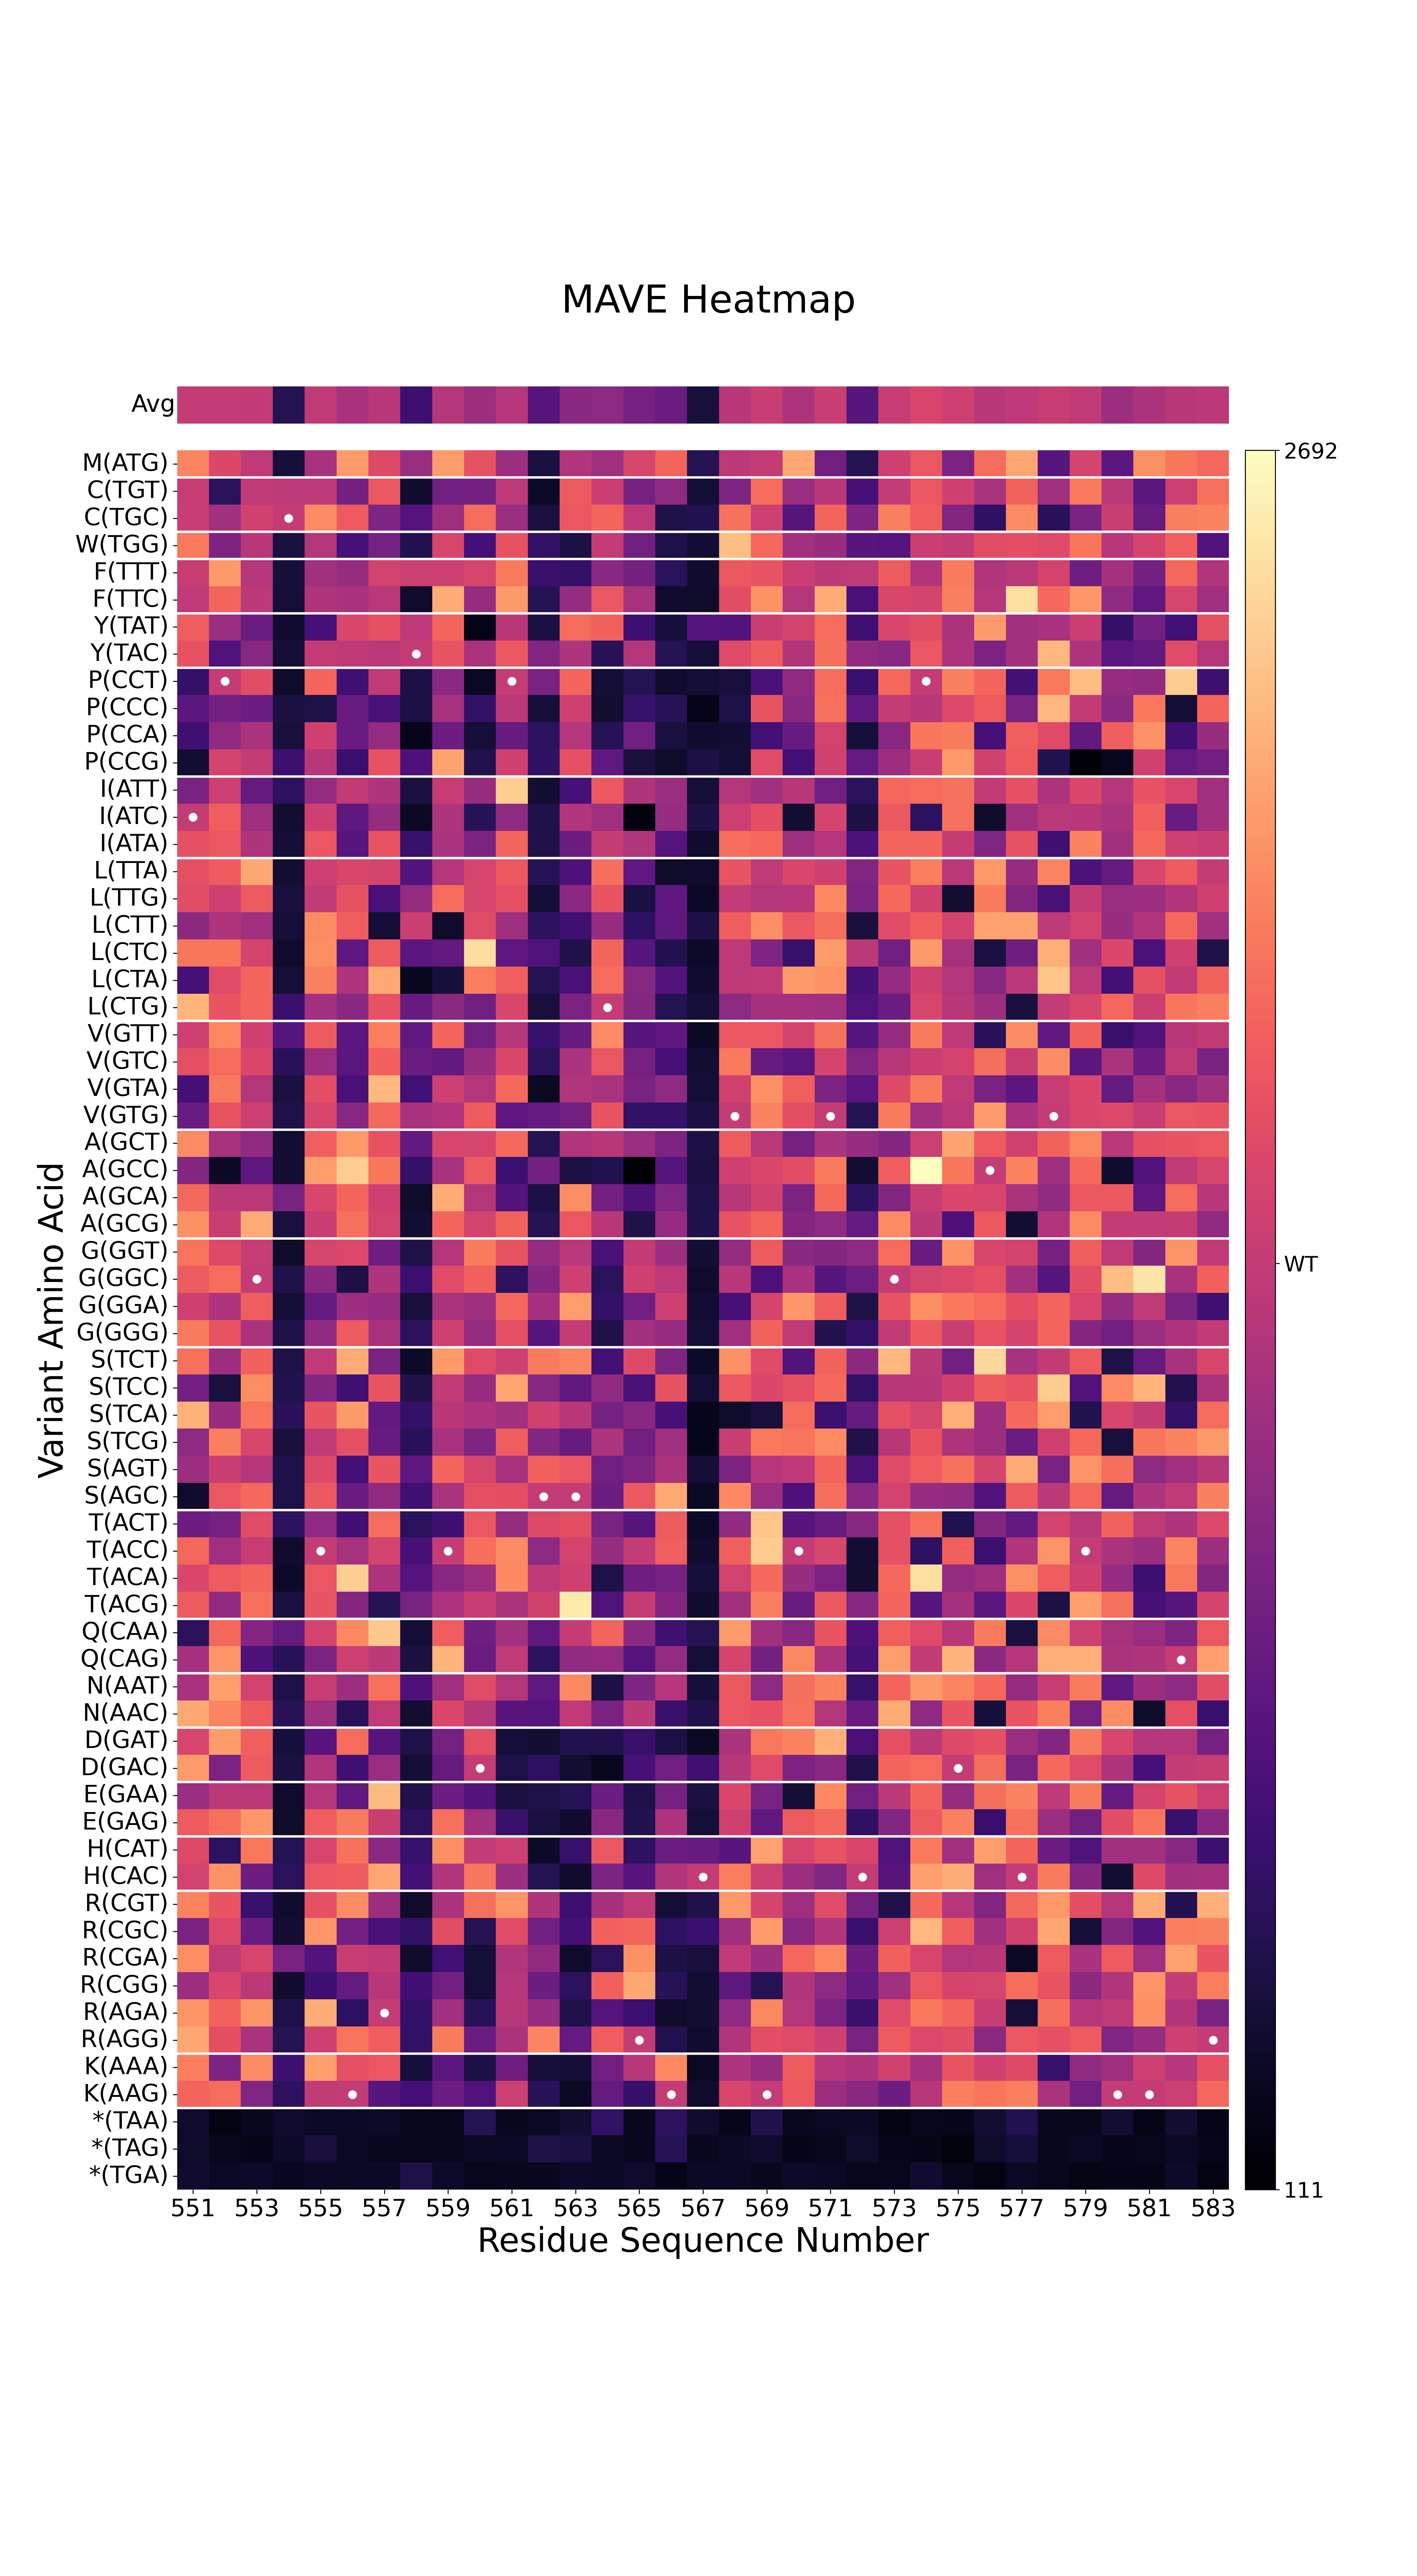

### Tile amino-acid heatmap (`test_multitile_regression_tile2_aa_heatmap.png`)

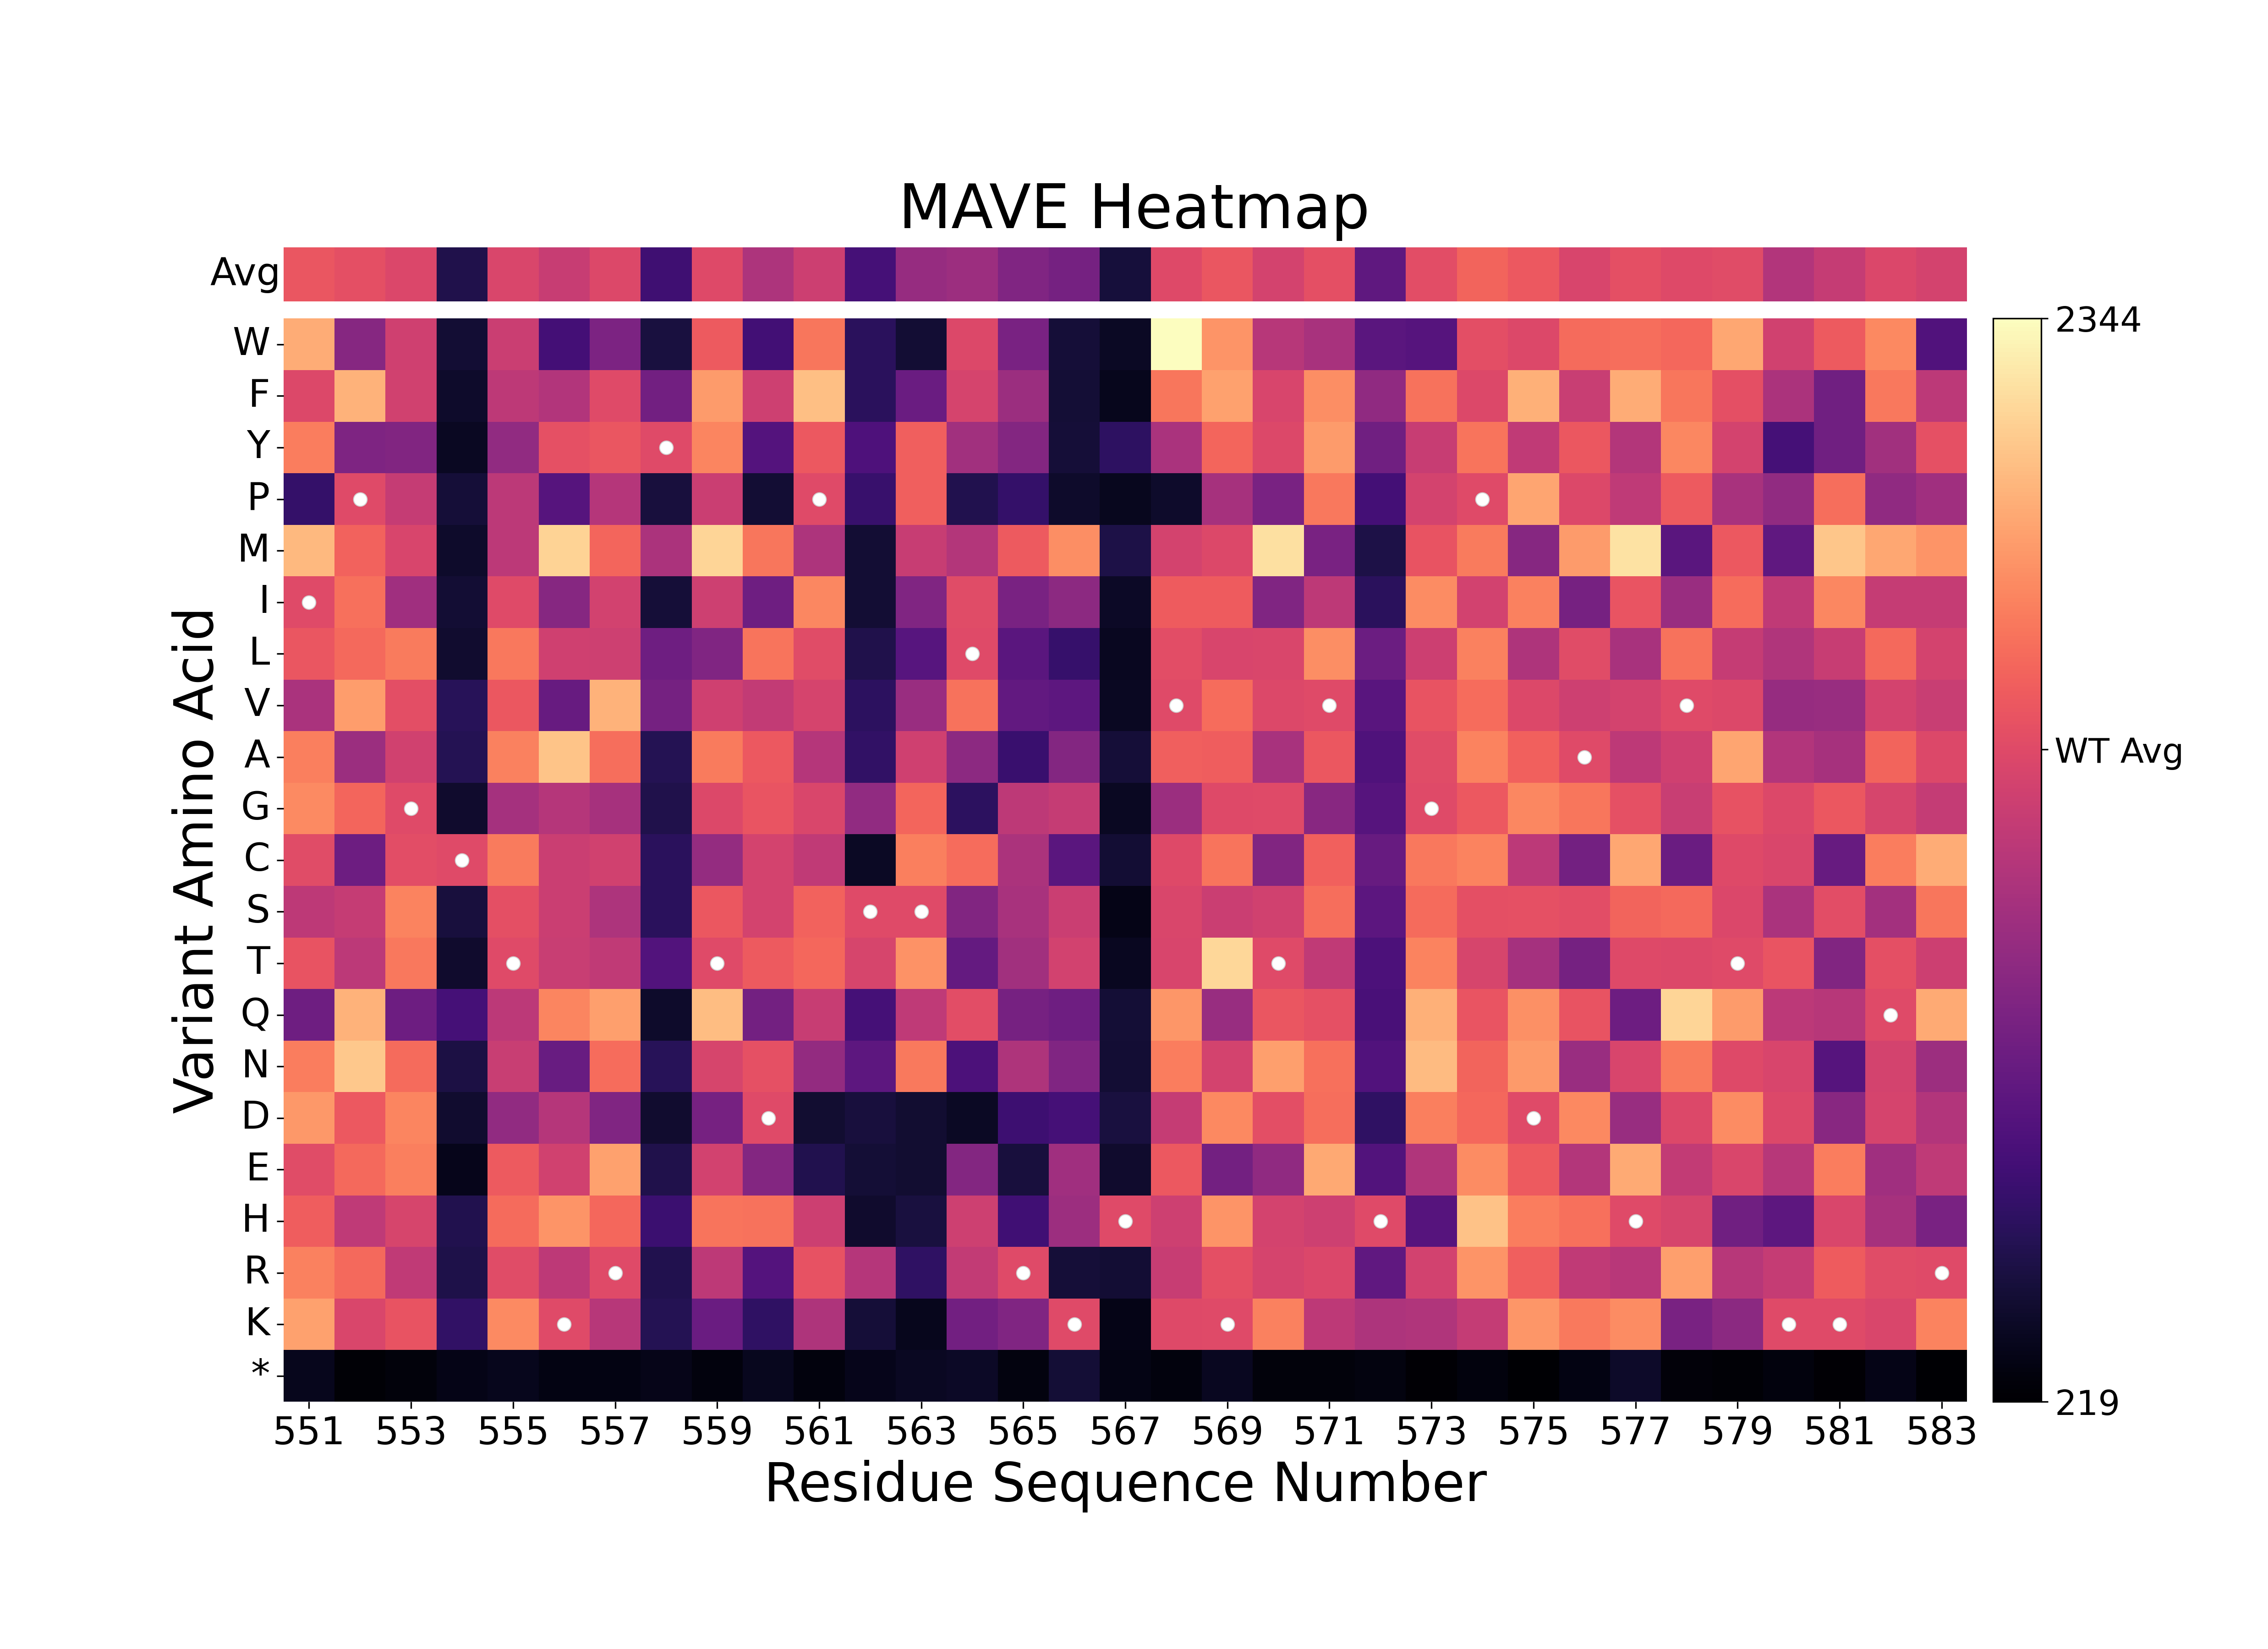

### Batch tiled heatmap (`tiled_heatmap.png`)

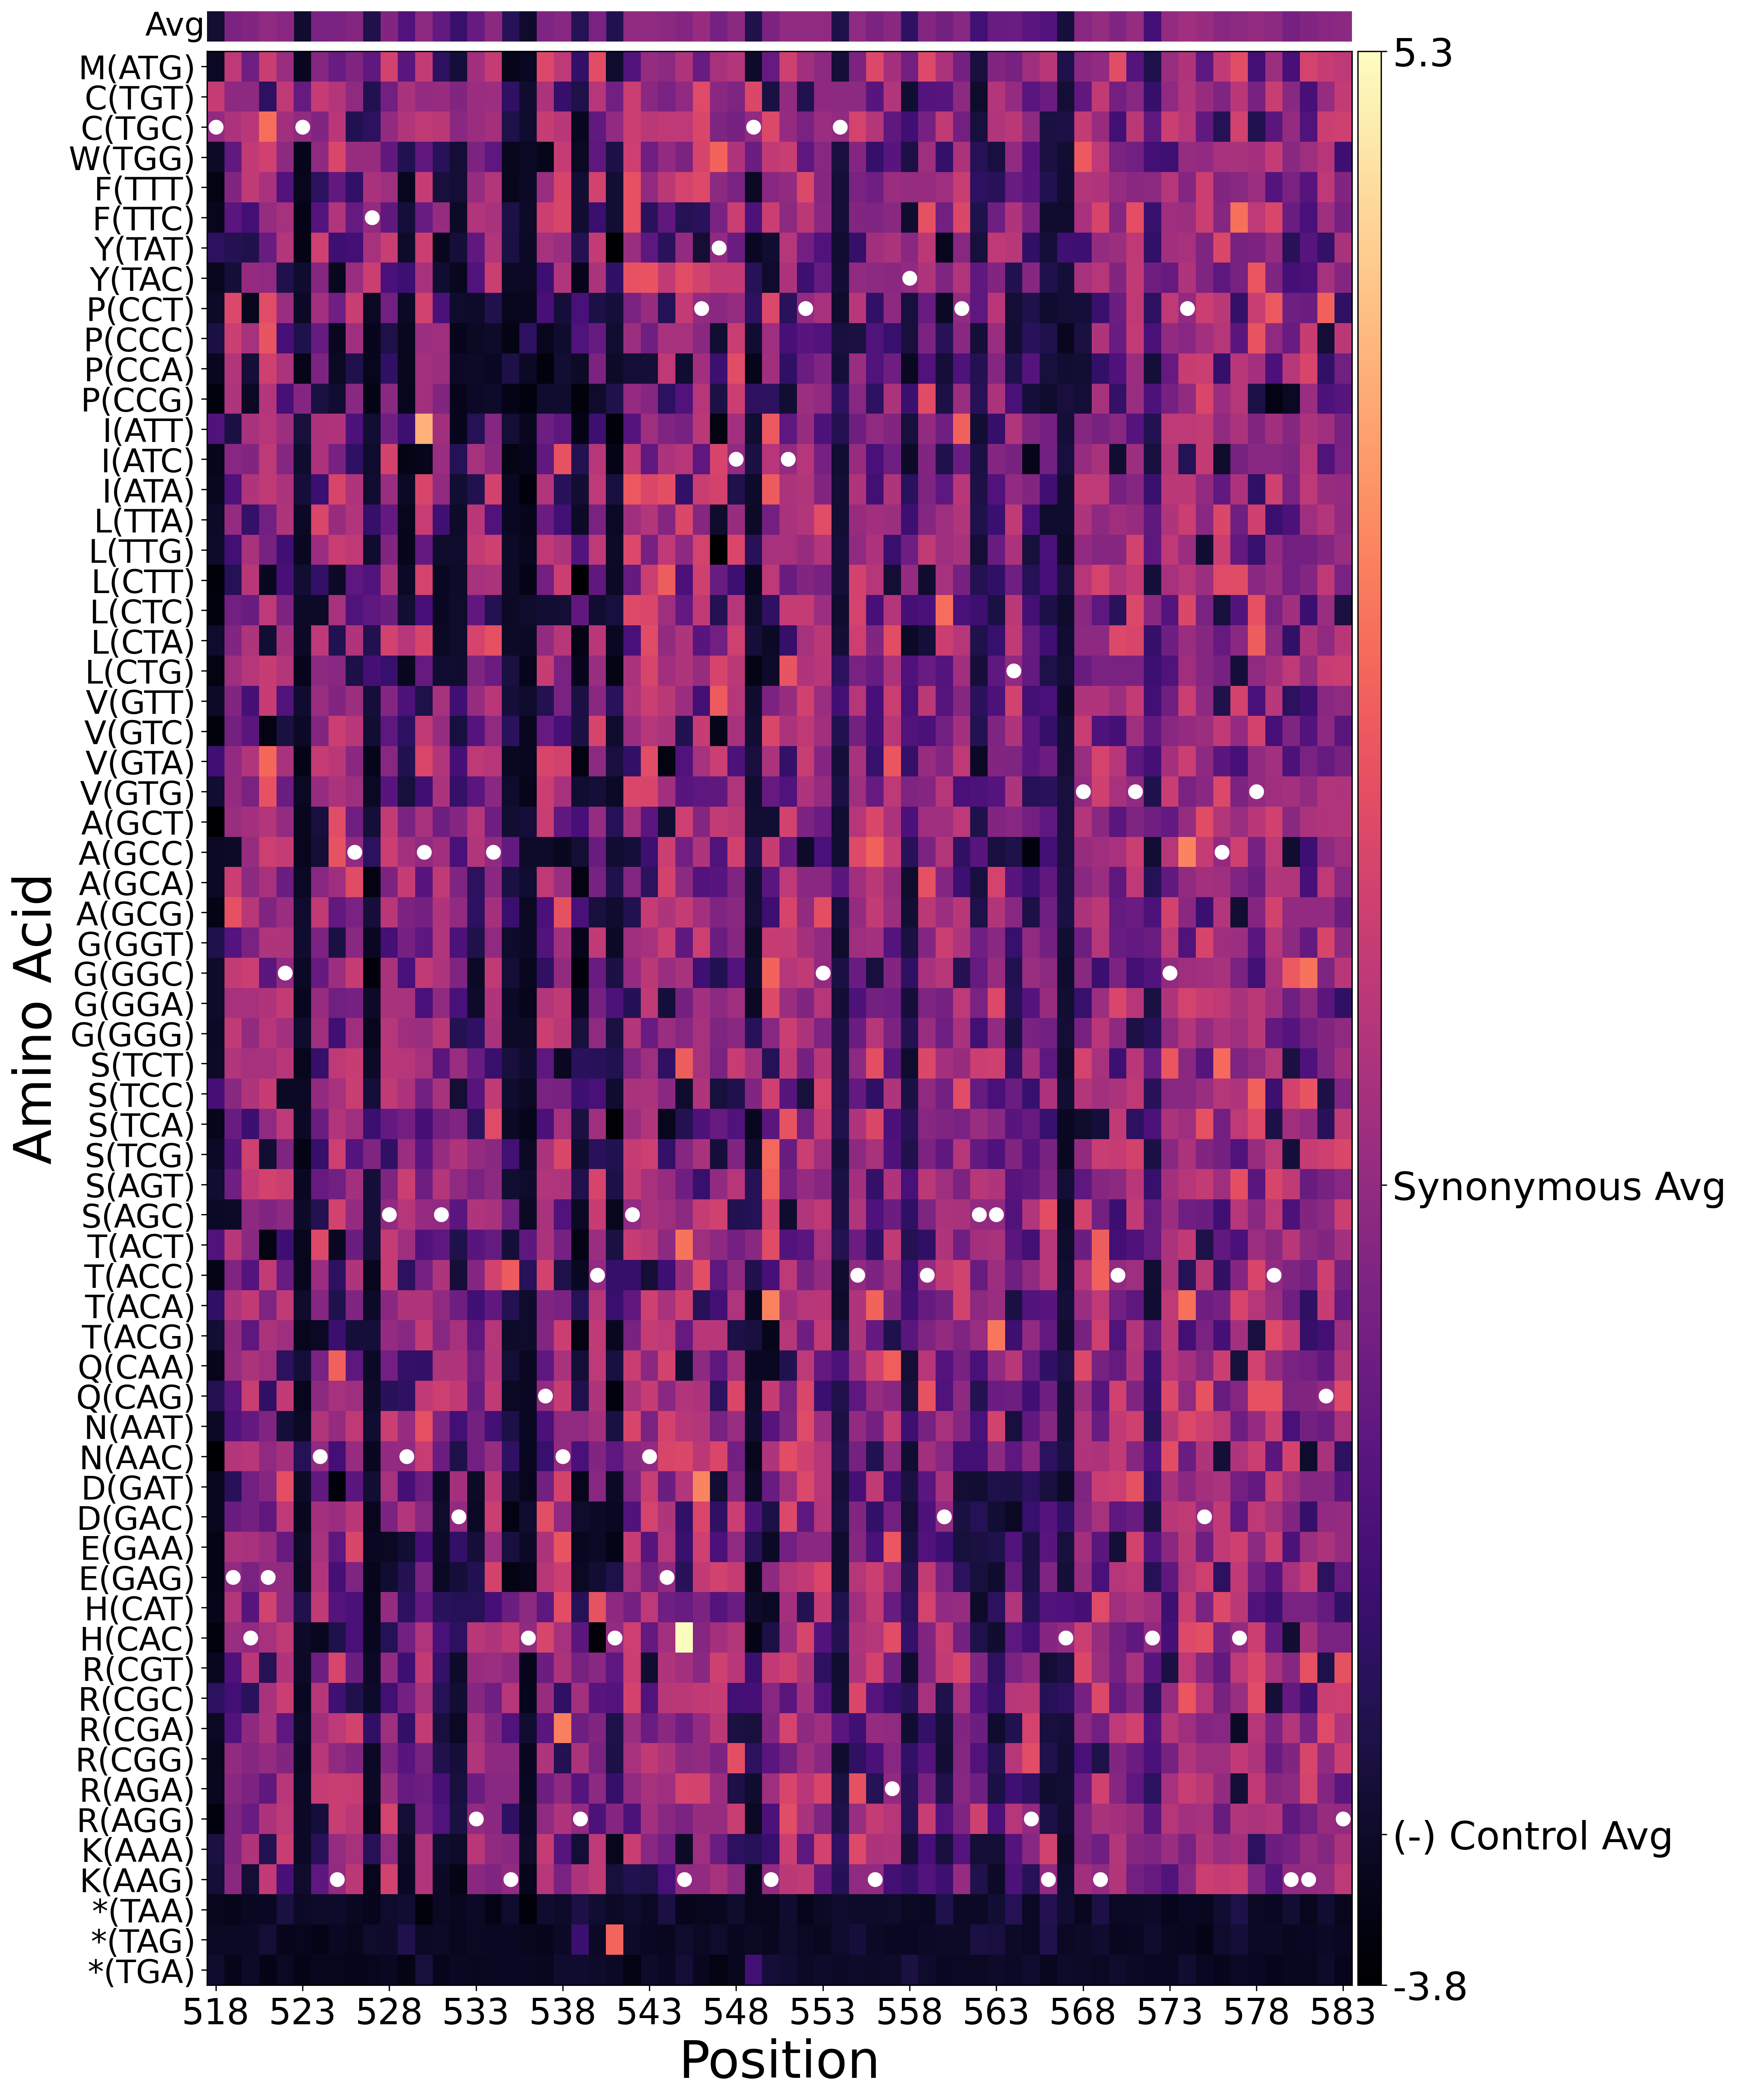

### Batch combined AA heatmap (`combined_aa_heatmap.png`)

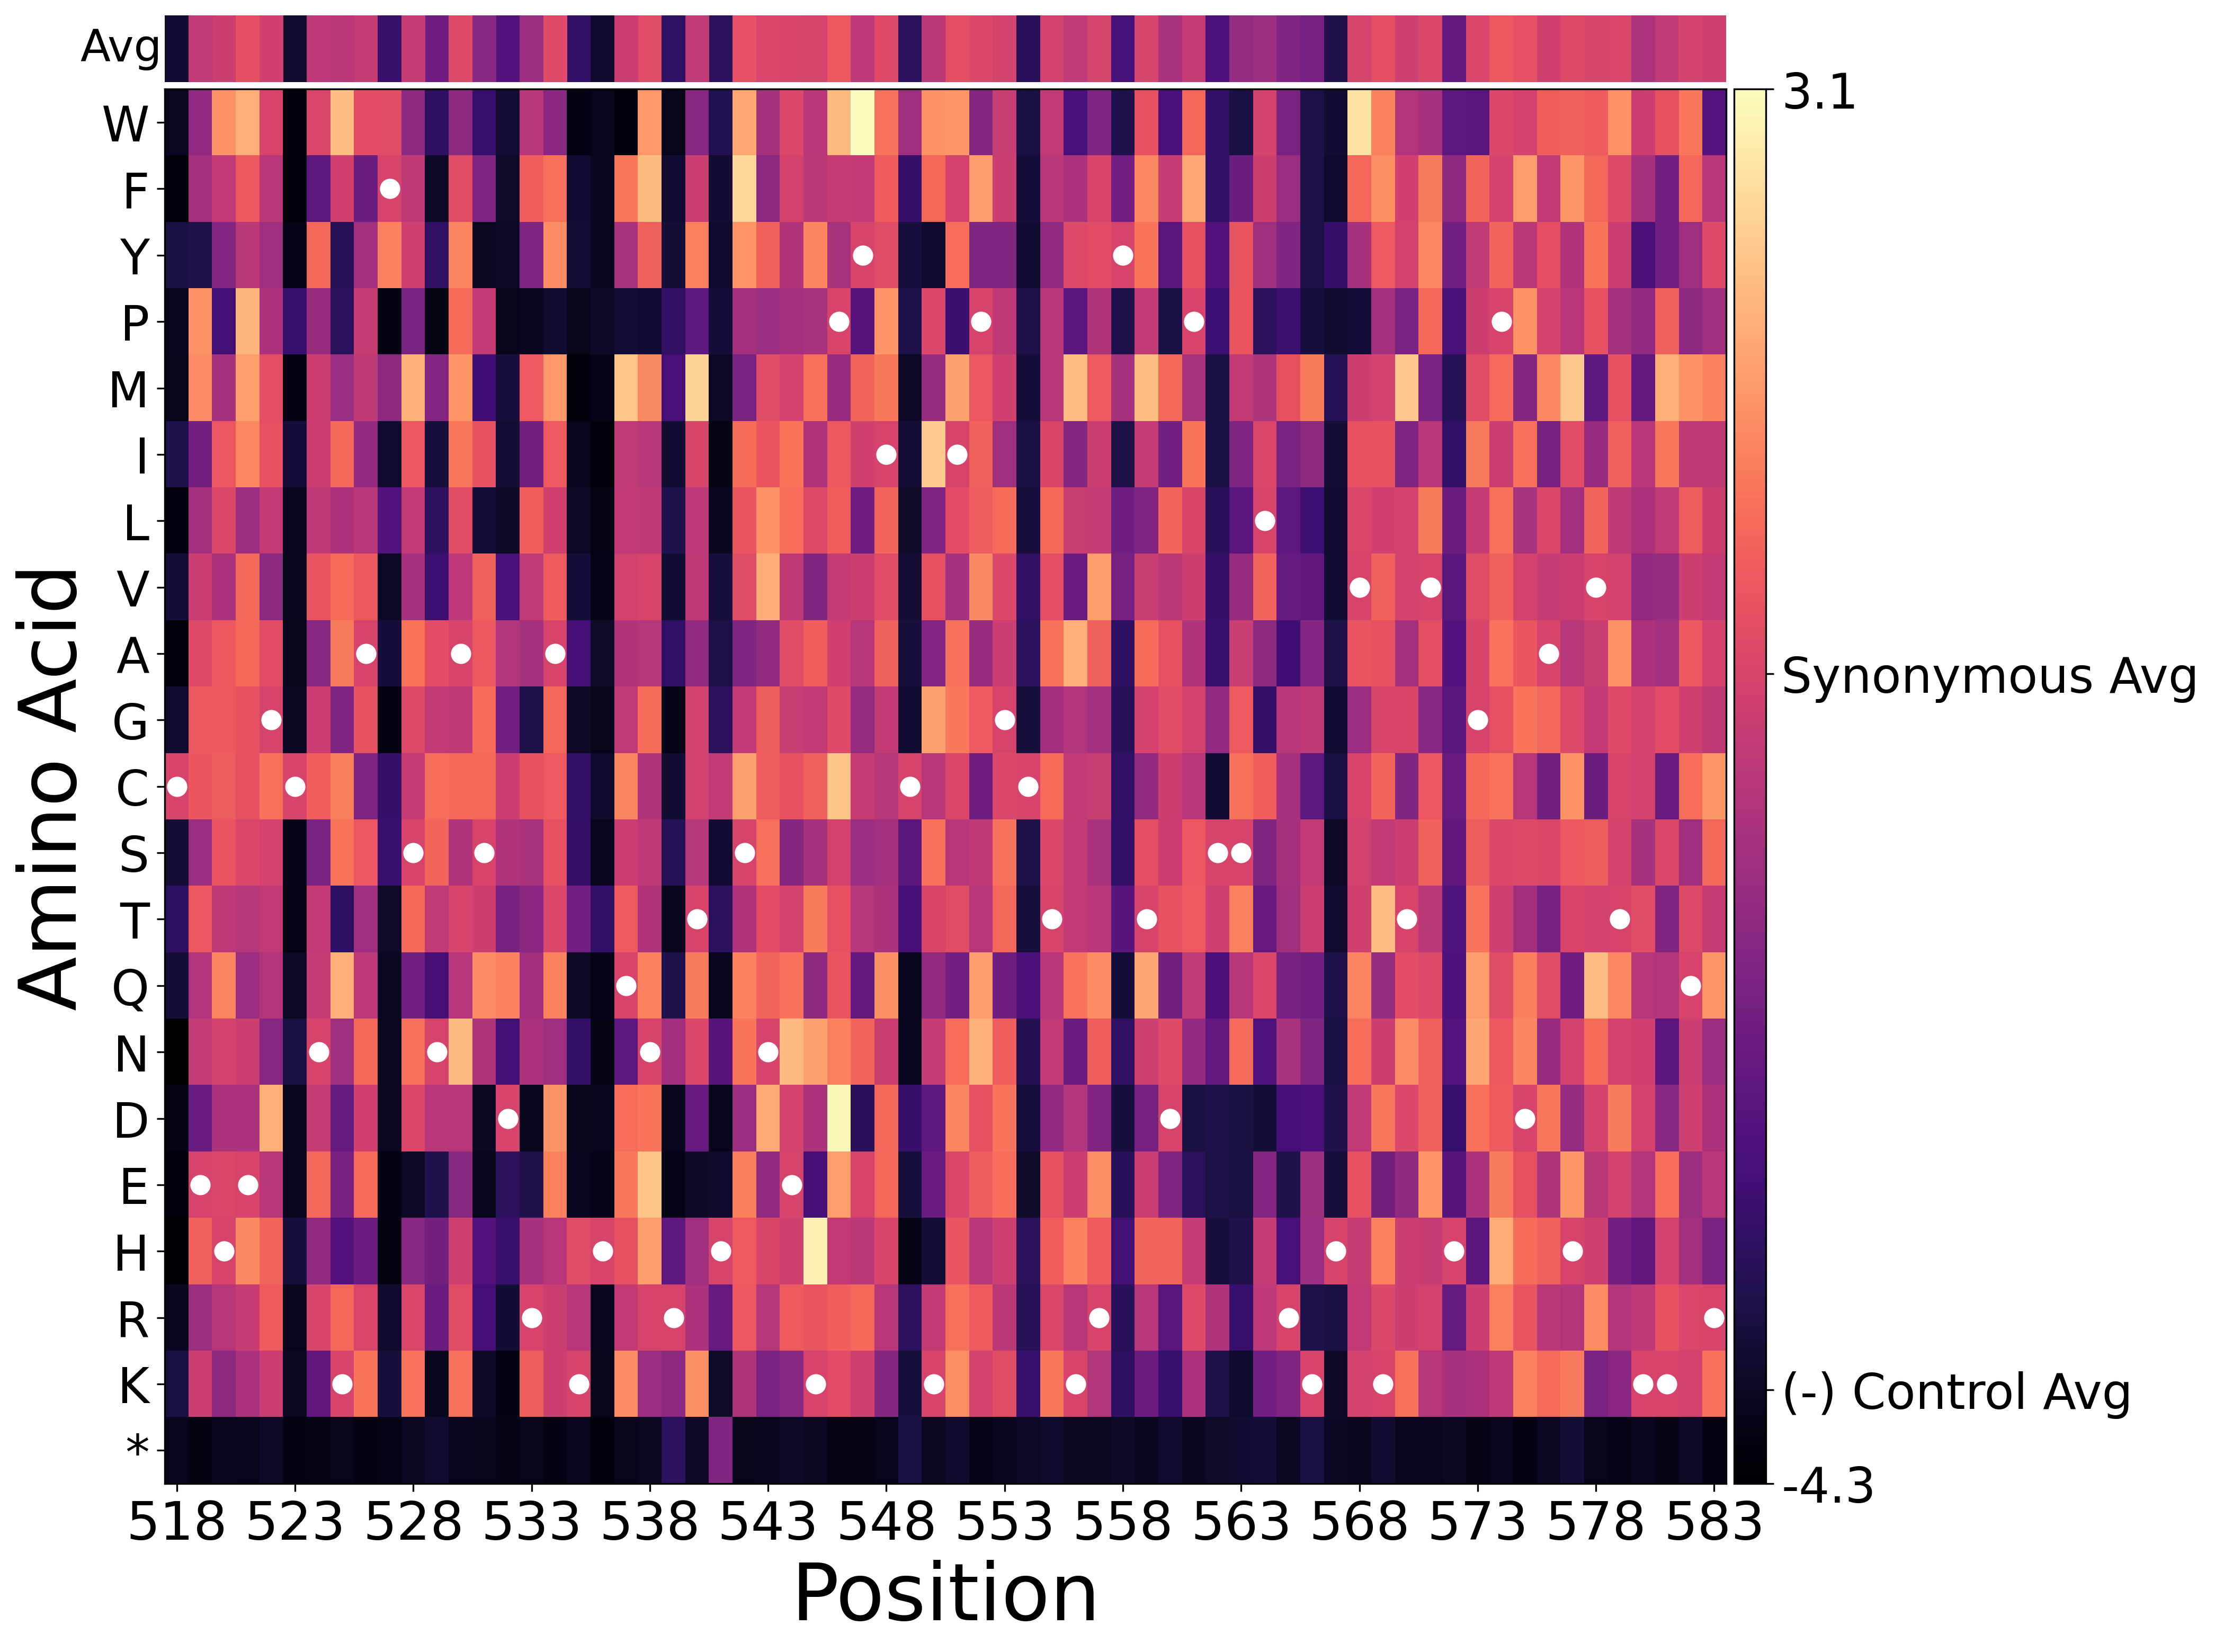

In [27]:
if codon_heatmap_file is None or not codon_heatmap_file.exists():
    location = codon_heatmap_file if codon_heatmap_file is not None else "<unresolved>"
    print(f"No codon heatmap image found for this tile at {location}.")
else:
    display(Markdown(f"### Tile codon heatmap (`{codon_heatmap_file.name}`)"))
    display(Image(filename=str(codon_heatmap_file)))

if aa_heatmap_file is None or not aa_heatmap_file.exists():
    location = aa_heatmap_file if aa_heatmap_file is not None else "<unresolved>"
    print(f"No amino-acid heatmap image found for this tile at {location}.")
else:
    display(Markdown(f"### Tile amino-acid heatmap (`{aa_heatmap_file.name}`)"))
    display(Image(filename=str(aa_heatmap_file)))

if not tiled_heatmap_file.exists():
    print(f"No tiled batch heatmap image found at {tiled_heatmap_file}.")
else:
    display(Markdown(f"### Batch tiled heatmap (`{tiled_heatmap_file.name}`)"))
    display(Image(filename=str(tiled_heatmap_file)))

if not combined_aa_heatmap_file.exists():
    print(f"No combined AA batch heatmap image found at {combined_aa_heatmap_file}.")
else:
    display(Markdown(f"### Batch combined AA heatmap (`{combined_aa_heatmap_file.name}`)"))
    display(Image(filename=str(combined_aa_heatmap_file)))
